In [111]:
# Install Required Packages
# Uncomment if required
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install e3nn
!pip install ase
!pip install matplotlib

In [112]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [113]:
# Synthetic Molecular Dataset
ELEMENTS = {
    0: [1,0,0],   # Carbon
    1: [0,1,0],   # Oxygen
    2: [0,0,1]    # Hydrogen
}


def create_mock_tribo_dataset(
        num_samples=100,
        num_atoms=30
    ):

    dataset=[]

    for sample in range(num_samples):

        # Random atom positions
        pos=torch.randn(num_atoms,3)

        # Random atom types
        atom_ids=np.random.randint(
            0,
            3,
            size=num_atoms
        )

        x=torch.tensor(
            [ELEMENTS[i] for i in atom_ids],
            dtype=torch.float
        )

        # Synthetic energy function
        energy=0.05*(pos**2).sum()

        data=Data(
            x=x,
            pos=pos,
            y=energy.unsqueeze(0)
        )

        dataset.append(data)

    return dataset

In [114]:
dataset=create_mock_tribo_dataset(
    num_samples=100,
    num_atoms=25
)

print("Dataset Size :",len(dataset))

print(dataset[0])

Dataset Size : 100
Data(x=[25, 3], y=[1], pos=[25, 3])


In [115]:
train_dataset=dataset[:80]

val_dataset=dataset[80:]

train_loader=DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

print("Training Samples :",len(train_dataset))
print("Validation Samples :",len(val_dataset))

Training Samples : 80
Validation Samples : 20


In [116]:
# Manual Radius Graph Construction
def radius_graph_manual(pos, radius=3.5, batch=None):
    """
    Pure PyTorch implementation of radius_graph.
    Creates edges between atoms within the cutoff radius.
    """

    device = pos.device

    if batch is None:
        batch = torch.zeros(
            pos.size(0),
            dtype=torch.long,
            device=device
        )

    edge_src = []
    edge_dst = []

    for b in batch.unique():

        idx = (batch == b).nonzero(as_tuple=False).view(-1)

        coords = pos[idx]

        # Pairwise distances
        dist = torch.cdist(coords, coords)

        # Remove self-loops
        mask = (dist < radius) & (dist > 0)

        src, dst = mask.nonzero(as_tuple=True)

        edge_src.append(idx[src])
        edge_dst.append(idx[dst])

    edge_src = torch.cat(edge_src)
    edge_dst = torch.cat(edge_dst)

    edge_index = torch.stack(
        [edge_src, edge_dst],
        dim=0
    )

    return edge_index

In [117]:
class DifferentiableMD(nn.Module):

    def __init__(self):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(4,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self,data):
        pos = data.pos.clone().detach().requires_grad_(True)
        edge_index = radius_graph_manual(
            pos,
            radius=3.5,
            batch=data.batch
        )

        row,col = edge_index
        edge_vector = pos[col]-pos[row]
        edge_length = edge_vector.norm(
            dim=1,
            keepdim=True
        )
        edge_features = torch.cat(
            [
                data.x[row],
                edge_length
            ],
            dim=1
        )
        edge_energy = self.edge_mlp(
            edge_features
        ).squeeze()

        node_energy = torch.zeros(
            pos.size(0),
            device=pos.device
        )
        node_energy.index_add_(
            0,
            row,
            edge_energy
        )

        num_graphs = int(data.batch.max())+1
        energy = torch.zeros(
            num_graphs,
            device=pos.device
        )
        energy.index_add_(
            0,
            data.batch,
            node_energy
        )

        forces = None
        if self.training: # Only compute forces if the model is in training mode
            forces = -torch.autograd.grad(
                outputs=energy.sum(),
                inputs=pos,
                create_graph=True
            )[0]

        return energy,forces

In [118]:
# Model Initialization
model = DifferentiableMD().to(device)

print(model)

DifferentiableMD(
  (edge_mlp): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [119]:
# Optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3

)

In [120]:
# Test Forward Pass
sample = next(iter(train_loader))

sample = sample.to(device)

energy,forces = model(sample)

print("Predicted Energy Shape :",energy.shape)

print("Force Tensor Shape :",forces.shape)

print()

print("Predicted Energy")

print(energy)

Predicted Energy Shape : torch.Size([8])
Force Tensor Shape : torch.Size([200, 3])

Predicted Energy
tensor([-26.7801, -23.6199, -24.6816, -25.1948, -25.4012, -25.7768, -24.6233,
        -24.1314], grad_fn=<IndexAddBackward0>)


In [121]:
# Train Model

epochs = 20

train_losses = []

model.train()

for epoch in range(epochs):

    running_loss = 0.0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        pred_energy, pred_force = model(batch)

        target_energy = batch.y.view(-1)

        loss = criterion(
            pred_energy,
            target_energy
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1:02d}/{epochs}] "
        f"Loss = {epoch_loss:.6f}"
    )

Epoch [01/20] Loss = 236.996026
Epoch [02/20] Loss = 44.382888
Epoch [03/20] Loss = 20.351699
Epoch [04/20] Loss = 8.486253
Epoch [05/20] Loss = 4.464426
Epoch [06/20] Loss = 3.748562
Epoch [07/20] Loss = 2.690423
Epoch [08/20] Loss = 2.363688
Epoch [09/20] Loss = 2.347604
Epoch [10/20] Loss = 1.855845
Epoch [11/20] Loss = 1.571607
Epoch [12/20] Loss = 1.470928
Epoch [13/20] Loss = 1.661950
Epoch [14/20] Loss = 1.135241
Epoch [15/20] Loss = 1.053556
Epoch [16/20] Loss = 1.084609
Epoch [17/20] Loss = 1.266436
Epoch [18/20] Loss = 0.687831
Epoch [19/20] Loss = 0.782503
Epoch [20/20] Loss = 1.275479


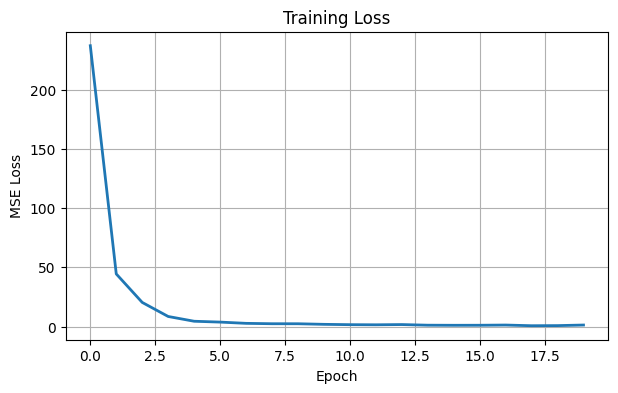

In [122]:
# Training Curve
plt.figure(figsize=(7,4))

plt.plot(
    train_losses,
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

In [123]:
# Validation
model.eval()

total_loss = 0

with torch.no_grad():

    for batch in val_loader:

        batch = batch.to(device)

        pred_energy, _ = model(batch)

        loss = criterion(
            pred_energy,
            batch.y.view(-1)
        )

        total_loss += loss.item()

validation_loss = total_loss / len(val_loader)

print("Validation Loss :", validation_loss)

Validation Loss : 2.228230031579733


In [124]:
import torch
# Predict One Molecule

sample = next(iter(val_loader))

sample = sample.to(device)

# Set model to training mode temporarily to enable force calculation
model.train()

with torch.enable_grad():

    energy, forces = model(sample)

# Optionally set it back to eval mode if further evaluation is expected
# model.eval()

print()

print("Predicted Energy")

print(energy)

print()

print("Force Tensor Shape")

print(forces.shape)

print()

print("First Five Force Vectors")

print(forces[:5])


Predicted Energy
tensor([2.2926], grad_fn=<IndexAddBackward0>)

Force Tensor Shape
torch.Size([25, 3])

First Five Force Vectors
tensor([[ 0.0363, -0.0358,  0.0990],
        [-0.0017, -0.0307,  0.1644],
        [-0.0464,  0.0197,  0.0767],
        [-0.0195, -0.0419, -0.0160],
        [ 0.1818,  0.0595, -0.0640]], grad_fn=<SliceBackward0>)


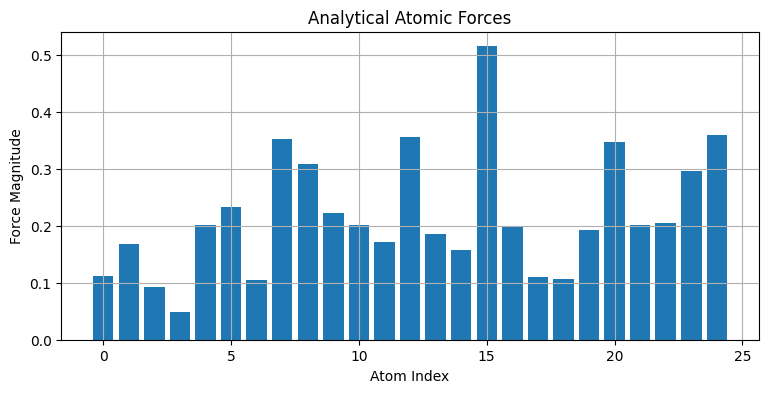

In [125]:
# Force Magnitudes
force_magnitude = forces.norm(
    dim=1
).detach().cpu().numpy()

plt.figure(figsize=(9,4))

plt.bar(
    np.arange(len(force_magnitude)),
    force_magnitude
)

plt.xlabel("Atom Index")

plt.ylabel("Force Magnitude")

plt.title("Analytical Atomic Forces")

plt.grid(True)

plt.show()

In [126]:
# Save Model
torch.save(
    model.state_dict(),
    "Differentiable_MD_Model.pth"
)

print("Model saved successfully.")

Model saved successfully.
